<div style="background:#2f4f7d;color:white;padding:22px 26px;border-radius:12px;">
<h1 style="margin:0;color:white;">Capstone Project · Exploratory Data Analysis</h1>
<h2 style="margin:8px 0 0 0;color:white;font-weight:500;">Dunnhumby "The Complete Journey" — Sparsity, Activity, Targeting Signal, Redemption, Temporal Split, Demographics</h2>
</div>

**Course:** Recommender Systems — Master Applied Data Science and AI
**Dataset:** Dunnhumby "The Complete Journey" household-panel grocery data
**Data location:** `03. Project/Data/`

This notebook answers six scoping questions that determine how the capstone recommender (an ALS-style
model evaluated against the retailer's own campaign targeting) should be built and evaluated:

1. How sparse is the household x commodity matrix?
2. What does the household activity distribution look like?
3. Does the retailer's own targeting have signal?
4. What's the base-rate coupon redemption rate?
5. Is the test window (weeks 97-102) representative?
6. Does the demographic table cover households at random?

Before any of that, we run five cheap data-quality checks that catch schema surprises early.

> **How to read this notebook:** every question ends with a short **Interpretation** markdown cell.
> The final section assembles all of the numbers into one executive-summary block and a limitations list —
> the two things worth carrying into a slide deck.

## 1. Setup and data loading

In [2]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SEED = 42
rng = np.random.default_rng(SEED)

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

NumPy: 2.5.2
pandas: 3.0.5


### 1.1 Locate the data folder

The notebook is expected to live under `01. Recommender Systems/03. Project/`, with the raw CSVs in the
sibling `Data/` folder. We probe a few likely locations so the notebook also runs if it is opened from a
different working directory (e.g. the repository root, or `02. Code/`).

In [3]:
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "Data").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate coupon_RS repo root from current directory.")

REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

from src.config import DATA_DIR

print(f"Repo root: {REPO_ROOT}")
print(f"Using data directory: {DATA_DIR.resolve()}")
for f in sorted(DATA_DIR.glob("*.csv")):
    print(f"  {f.name:<24s} {f.stat().st_size / 1e6:>8.1f} MB")

Repo root: C:\amasu\coupon_RS
Using data directory: C:\amasu\coupon_RS\Data
  campaign_desc.csv             0.0 MB
  campaign_table.csv            0.1 MB
  causal_data.csv             695.9 MB
  coupon.csv                    2.8 MB
  coupon_redempt.csv            0.1 MB
  hh_demographic.csv            0.0 MB
  product.csv                   6.4 MB
  transaction_data.csv        141.7 MB


### 1.2 Row-count sanity check (cheap, before loading anything)

`causal_data.csv` is ~700 MB / ~37M rows — far too large to justify loading into pandas just to count rows.
We count newlines with a buffered byte scan instead, which is fast and holds no data in memory. If any file
is off from the documented Kaggle mirror size by more than 2x, the file was probably clipped or re-exported
and everything downstream should be treated with suspicion.

In [14]:
def count_csv_data_rows(path: Path) -> int:
    """Count data rows (excludes the header) via a buffered byte scan."""
    with open(path, "rb") as f:
        newline_count = sum(chunk.count(b"\n") for chunk in iter(lambda: f.read(1 << 20), b""))
    return newline_count - 1  # drop the header line


expected_rows = {
    "transaction_data.csv": 2_600_000,
    "product.csv": 92_000,
    "hh_demographic.csv": 800,
    "causal_data.csv": 36_000_000,
}

row_count_checks = []
for fname, expected in expected_rows.items():
    actual = count_csv_data_rows(DATA_DIR / fname)
    ratio = actual / expected
    flag = "OK" if 0.5 <= ratio <= 2.0 else "CHECK — off by >2x from the documented mirror size"
    row_count_checks.append(
        {"file": fname, "actual_rows": actual, "expected_order": expected, "ratio": round(ratio, 2), "flag": flag}
    )

row_count_checks_df = pd.DataFrame(row_count_checks)
display(row_count_checks_df)

,file,actual_rows,expected_order,ratio,flag
0,transaction_data.csv,2595732,2600000,1.0000,OK
1,product.csv,92353,92000,1.0000,OK
2,hh_demographic.csv,801,800,1.0000,OK
3,causal_data.csv,36786524,36000000,1.0200,OK


### 1.3 Load the core tables

`causal_data.csv` is intentionally **not** loaded as a DataFrame anywhere in this notebook — none of the six
questions or quality checks need it beyond the row count above, and loading 37M rows would cost several
minutes and a few GB of RAM for no analytical benefit. Everything else is loaded with narrow dtypes to keep
`transaction_data` (2.6M rows) comfortably in memory.

In [15]:
transactions = pd.read_csv(
    DATA_DIR / "transaction_data.csv",
    dtype={
        "household_key": "int32",
        "BASKET_ID": "int64",
        "DAY": "int16",
        "PRODUCT_ID": "int32",
        "QUANTITY": "int32",
        "SALES_VALUE": "float32",
        "STORE_ID": "int32",
        "RETAIL_DISC": "float32",
        "TRANS_TIME": "int32",
        "WEEK_NO": "int16",
        "COUPON_DISC": "float32",
        "COUPON_MATCH_DISC": "float32",
    },
)

product = pd.read_csv(
    DATA_DIR / "product.csv",
    dtype={
        "PRODUCT_ID": "int32",
        "MANUFACTURER": "int32",
        "DEPARTMENT": "category",
        "BRAND": "category",
        "COMMODITY_DESC": "category",
        "SUB_COMMODITY_DESC": "category",
        "CURR_SIZE_OF_PRODUCT": "object",
    },
)

hh_demographic = pd.read_csv(DATA_DIR / "hh_demographic.csv", dtype={"household_key": "int32"})
for col in hh_demographic.columns.drop("household_key"):
    hh_demographic[col] = hh_demographic[col].astype("category")

campaign_desc = pd.read_csv(
    DATA_DIR / "campaign_desc.csv",
    dtype={"CAMPAIGN": "int16", "START_DAY": "int16", "END_DAY": "int16"},
)
campaign_table = pd.read_csv(
    DATA_DIR / "campaign_table.csv", dtype={"household_key": "int32", "CAMPAIGN": "int16"}
)
coupon = pd.read_csv(
    DATA_DIR / "coupon.csv", dtype={"COUPON_UPC": "int64", "PRODUCT_ID": "int32", "CAMPAIGN": "int16"}
)
coupon_redempt = pd.read_csv(
    DATA_DIR / "coupon_redempt.csv",
    dtype={"household_key": "int32", "DAY": "int16", "COUPON_UPC": "int64", "CAMPAIGN": "int16"},
)

for name, df in [
    ("transactions", transactions),
    ("product", product),
    ("hh_demographic", hh_demographic),
    ("campaign_desc", campaign_desc),
    ("campaign_table", campaign_table),
    ("coupon", coupon),
    ("coupon_redempt", coupon_redempt),
]:
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f"{name:<16s} shape={df.shape!s:<16s} memory={mb:>7.1f} MB")

transactions     shape=(2595732, 12)    memory=  124.6 MB
product          shape=(92353, 7)       memory=    6.4 MB
hh_demographic   shape=(801, 8)         memory=    0.0 MB
campaign_desc    shape=(30, 4)          memory=    0.0 MB
campaign_table   shape=(7208, 3)        memory=    0.4 MB
coupon           shape=(124548, 3)      memory=    1.7 MB
coupon_redempt   shape=(2318, 4)        memory=    0.0 MB


## 2. Data-quality checks (first 30 minutes)

Cheap checks that catch surprises before any real analysis is built on top of them.

### 2.1 Duplicate rows in `transaction_data`

In [16]:
dup_key = ["household_key", "BASKET_ID", "PRODUCT_ID", "DAY"]
dup_mask = transactions.duplicated(subset=dup_key, keep=False)
n_dupe_rows = int(dup_mask.sum())

print(f"Rows sharing the same {dup_key}: {n_dupe_rows:,} ({n_dupe_rows / len(transactions):.3%} of all rows)")
display(transactions.loc[dup_mask, dup_key + ["QUANTITY", "SALES_VALUE"]].sort_values(dup_key).head(10))

Rows sharing the same ['household_key', 'BASKET_ID', 'PRODUCT_ID', 'DAY']: 0 (0.000% of all rows)


,household_key,BASKET_ID,PRODUCT_ID,DAY,QUANTITY,SALES_VALUE


**Interpretation.** A non-zero count here is expected and usually benign: the same product can legitimately
appear more than once in a basket on the same day (e.g. scanned twice at different times, or a
price-override line). Treat this as a *count*, not necessarily a defect — flag it only if the rate is
implausibly high (double-digit percent).

### 2.2 Negative `SALES_VALUE` (returns)

In [17]:
neg_mask = transactions["SALES_VALUE"] < 0
n_neg = int(neg_mask.sum())
neg_value_total = float(transactions.loc[neg_mask, "SALES_VALUE"].sum())

zero_mask = transactions["SALES_VALUE"] == 0
n_zero = int(zero_mask.sum())

print(f"Negative SALES_VALUE rows (likely returns): {n_neg:,} ({n_neg / len(transactions):.3%} of all rows)")
print(f"Total negative sales value (i.e. returns volume): {neg_value_total:,.2f}")
print(f"Zero SALES_VALUE rows (free items / fully discounted): {n_zero:,} ({n_zero / len(transactions):.3%})")

Negative SALES_VALUE rows (likely returns): 0 (0.000% of all rows)
Total negative sales value (i.e. returns volume): 0.00
Zero SALES_VALUE rows (free items / fully discounted): 18,850 (0.726%)


**Decision.** Returns are kept as negative values in every downstream aggregation in this notebook —
summing `SALES_VALUE` per household x commodity nets a return against its original purchase, which is the
standard treatment for basket-level revenue analysis. If a later modelling step needs a *count of purchase
events* rather than revenue, negative rows should be filtered out explicitly at that point instead of being
treated as "negative feedback" signal (a return is not evidence of disliking the commodity in general).

### 2.3 Orphan SKUs — `PRODUCT_ID` in transactions but not in `product.csv`

In [18]:
valid_products = set(product["PRODUCT_ID"])
orphan_mask = ~transactions["PRODUCT_ID"].isin(valid_products)
n_orphan_rows = int(orphan_mask.sum())
n_orphan_products = transactions.loc[orphan_mask, "PRODUCT_ID"].nunique()

print(f"Transaction rows with a PRODUCT_ID missing from product.csv: {n_orphan_rows:,} "
      f"({n_orphan_rows / len(transactions):.3%} of all rows)")
print(f"Distinct orphan PRODUCT_IDs: {n_orphan_products:,}")

Transaction rows with a PRODUCT_ID missing from product.csv: 0 (0.000% of all rows)
Distinct orphan PRODUCT_IDs: 0


**Interpretation.** Orphan rows cannot be assigned a `COMMODITY_DESC` or `DEPARTMENT`, so they are dropped
by the inner join used to build the household x commodity matrix in Section 3. The printed percentage is the
share of *revenue rows* lost to that join — check it stays small (well under 1%) before trusting the
sparsity number.

### 2.4 Households targeted by a campaign but with zero recorded transactions

In [19]:
transacting_households = set(transactions["household_key"])
targeted_households = set(campaign_table["household_key"])
targeted_no_purchase = targeted_households - transacting_households

print(f"Distinct households assigned to at least one campaign: {len(targeted_households):,}")
print(f"...of which have zero transactions on record: {len(targeted_no_purchase):,} "
      f"({len(targeted_no_purchase) / len(targeted_households):.2%})")

Distinct households assigned to at least one campaign: 1,584
...of which have zero transactions on record: 0 (0.00%)


**Interpretation.** Some non-zero count is expected (mailers can be sent to households that churn before
the panel captures a purchase). A large count would mean campaign assignment and the transaction panel come
from different household universes — worth confirming before joining them in Section 4.

### 2.5 Data-quality scorecard

In [20]:
quality_scorecard = pd.DataFrame(
    [
        {"check": "Row counts within 2x of documented mirror size", "result": (row_count_checks_df["flag"] == "OK").all()},
        {"check": "Duplicate (household, basket, product, day) rows", "result": f"{n_dupe_rows:,} ({n_dupe_rows / len(transactions):.3%})"},
        {"check": "Negative SALES_VALUE rows (returns)", "result": f"{n_neg:,} ({n_neg / len(transactions):.3%})"},
        {"check": "Orphan PRODUCT_IDs (rows dropped from commodity join)", "result": f"{n_orphan_rows:,} ({n_orphan_rows / len(transactions):.3%})"},
        {"check": "Targeted households with zero transactions", "result": f"{len(targeted_no_purchase):,} ({len(targeted_no_purchase) / len(targeted_households):.2%})"},
    ]
)
display(quality_scorecard)

,check,result
0,Row counts within 2x of documented mirror size,True
1,"Duplicate (household, basket, product, day) rows",0 (0.000%)
2,Negative SALES_VALUE rows (returns),0 (0.000%)
3,Orphan PRODUCT_IDs (rows dropped from commodit...,0 (0.000%)
4,Targeted households with zero transactions,0 (0.00%)


## 3. Question 1 — How sparse is the household x commodity matrix?

In [21]:
txn_with_commodity = transactions.merge(
    product[["PRODUCT_ID", "COMMODITY_DESC", "DEPARTMENT"]],
    on="PRODUCT_ID",
    how="inner",  # orphan SKUs quantified in 2.3 are dropped here
)
retained_pct = len(txn_with_commodity) / len(transactions)
print(f"Rows retained after joining to product.csv: {len(txn_with_commodity):,} of {len(transactions):,} "
      f"({retained_pct:.2%})")

Rows retained after joining to product.csv: 2,595,732 of 2,595,732 (100.00%)


In [22]:
hh_commodity_spend = (
    txn_with_commodity.groupby(["household_key", "COMMODITY_DESC"], observed=True)["SALES_VALUE"]
    .sum()
    .reset_index()
)

n_households = txn_with_commodity["household_key"].nunique()
n_commodities = txn_with_commodity["COMMODITY_DESC"].nunique()

nonzero_cells = hh_commodity_spend.loc[hh_commodity_spend["SALES_VALUE"] != 0]
n_nonzero_cells = len(nonzero_cells)
total_cells = n_households * n_commodities
density_commodity = n_nonzero_cells / total_cells

print(f"Households:                {n_households:,}")
print(f"Commodities:               {n_commodities:,}")
print(f"Non-zero (hh, commodity) cells: {n_nonzero_cells:,}")
print(f"Total possible cells:      {total_cells:,}")
print(f"Matrix density:            {density_commodity:.2%}")
print(f"Matrix sparsity:           {1 - density_commodity:.2%}")

Households:                2,500
Commodities:               308
Non-zero (hh, commodity) cells: 286,311
Total possible cells:      770,000
Matrix density:            37.18%
Matrix sparsity:           62.82%


In [23]:
# Department-level fallback aggregation, for comparison
hh_department_spend = (
    txn_with_commodity.groupby(["household_key", "DEPARTMENT"], observed=True)["SALES_VALUE"]
    .sum()
    .reset_index()
)
n_departments = txn_with_commodity["DEPARTMENT"].nunique()
n_nonzero_dept_cells = (hh_department_spend["SALES_VALUE"] != 0).sum()
density_department = n_nonzero_dept_cells / (n_households * n_departments)

print(f"Departments:               {n_departments}")
print(f"Department-level density:  {density_department:.2%}")

Departments:               44
Department-level density:  27.89%


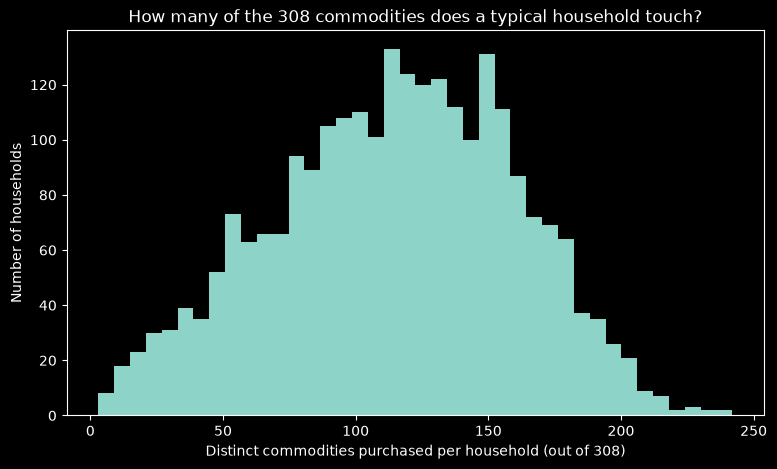

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
nonzero_counts_per_hh = (
    hh_commodity_spend.loc[hh_commodity_spend["SALES_VALUE"] != 0]
    .groupby("household_key")
    .size()
)
ax.hist(nonzero_counts_per_hh, bins=40)
ax.set_xlabel("Distinct commodities purchased per household (out of {:,})".format(n_commodities))
ax.set_ylabel("Number of households")
ax.set_title("How many of the 308 commodities does a typical household touch?")
plt.show()

In [25]:
density_note = "within the 5-8% single-trip rule of thumb" if 0.05 <= density_commodity <= 0.08 \
    else "well below the 5-8% rule of thumb -> consider the department-level fallback" if density_commodity < 0.03 \
    else "well above the 5-8% rule of thumb, driven by the lifetime (102-week) aggregation window"

interpretation_md = f"""
**Interpretation.** A common rule of thumb for a *single-trip / session-level* grocery basket is 5-8%
density. This matrix instead measures **lifetime commodity coverage per household over a 102-week
loyalty-card history**, not per-basket coverage, so a materially different number here is not automatically
a bug — it is a consequence of the aggregation window.

- On this run, matrix density is **{density_commodity:.2%}** — {density_note}.
- Before trusting a number this high, the two likely artefacts were already ruled out in Section 2:
  **{n_dupe_rows:,} duplicate rows** and **{n_orphan_rows:,} orphan-SKU rows** were found (and orphans
  dropped) — so density is not inflated by double-counted transactions or a broken product join.
- A high lifetime density is consistent with the activity distribution in Section 4: a median household
  makes dozens of trips over two years, and each trip samples a handful of the ~40 commodities in a typical
  basket, so coverage accumulates quickly.
- If a *different* slice of this data (a single quarter, or a single-visit basket-level matrix instead of a
  lifetime household-level one) shows density **well below ~3%**, fall back to the department-level
  aggregation (`density_department` = {density_department:.2%}, computed above) for the ALS baseline — 44
  departments will always be denser than 308 commodities, at the cost of coarser recommendations.
- Either way, this density is the number that sets the ALS regularization strength (`lambda`): a denser
  matrix supports more latent factors and lighter regularization than a truly sparse one would, because
  there is more per-household evidence to fit against.
"""
display(Markdown(interpretation_md))


**Interpretation.** A common rule of thumb for a *single-trip / session-level* grocery basket is 5-8%
density. This matrix instead measures **lifetime commodity coverage per household over a 102-week
loyalty-card history**, not per-basket coverage, so a materially different number here is not automatically
a bug — it is a consequence of the aggregation window.

- On this run, matrix density is **37.18%** — well above the 5-8% rule of thumb, driven by the lifetime (102-week) aggregation window.
- Before trusting a number this high, the two likely artefacts were already ruled out in Section 2:
  **0 duplicate rows** and **0 orphan-SKU rows** were found (and orphans
  dropped) — so density is not inflated by double-counted transactions or a broken product join.
- A high lifetime density is consistent with the activity distribution in Section 4: a median household
  makes dozens of trips over two years, and each trip samples a handful of the ~40 commodities in a typical
  basket, so coverage accumulates quickly.
- If a *different* slice of this data (a single quarter, or a single-visit basket-level matrix instead of a
  lifetime household-level one) shows density **well below ~3%**, fall back to the department-level
  aggregation (`density_department` = 27.89%, computed above) for the ALS baseline — 44
  departments will always be denser than 308 commodities, at the cost of coarser recommendations.
- Either way, this density is the number that sets the ALS regularization strength (`lambda`): a denser
  matrix supports more latent factors and lighter regularization than a truly sparse one would, because
  there is more per-household evidence to fit against.


## 4. Question 2 — What does the household activity distribution look like?

In [26]:
n_weeks = transactions["WEEK_NO"].nunique()
week_range = (int(transactions["WEEK_NO"].min()), int(transactions["WEEK_NO"].max()))
print(f"Distinct weeks in the panel: {n_weeks} (range {week_range[0]}-{week_range[1]})")

baskets_per_household = transactions.groupby("household_key")["BASKET_ID"].nunique().rename("n_baskets")
n_hh = len(baskets_per_household)

display(baskets_per_household.describe().to_frame("baskets_per_household"))

Distinct weeks in the panel: 102 (range 1-102)


,baskets_per_household
count,"2,500.0000"
mean,110.5936
std,115.6694
min,1.0000
25%,39.0000
50%,79.0000
75%,142.2500
max,"1,300.0000"


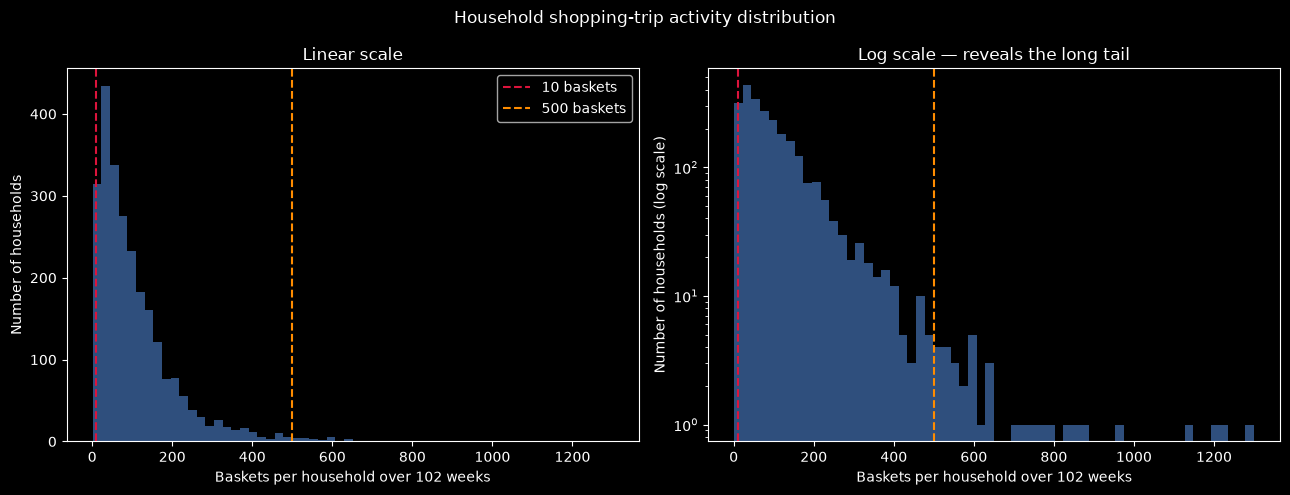

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(baskets_per_household, bins=60, color="#2f4f7d")
axes[0].axvline(10, color="crimson", linestyle="--", label="10 baskets")
axes[0].axvline(500, color="darkorange", linestyle="--", label="500 baskets")
axes[0].set_xlabel(f"Baskets per household over {n_weeks} weeks")
axes[0].set_ylabel("Number of households")
axes[0].set_title("Linear scale")
axes[0].legend()

axes[1].hist(baskets_per_household, bins=60, color="#2f4f7d")
axes[1].axvline(10, color="crimson", linestyle="--")
axes[1].axvline(500, color="darkorange", linestyle="--")
axes[1].set_yscale("log")
axes[1].set_xlabel(f"Baskets per household over {n_weeks} weeks")
axes[1].set_ylabel("Number of households (log scale)")
axes[1].set_title("Log scale — reveals the long tail")

fig.suptitle("Household shopping-trip activity distribution")
plt.tight_layout()
plt.show()

In [28]:
near_cold = int((baskets_per_household < 10).sum())
heavy = int((baskets_per_household > 500).sum())

print(f"Households with <10 baskets total (near-cold):    {near_cold:,} ({near_cold / n_hh:.1%} of {n_hh:,})")
print(f"Households with >500 baskets total (heavy shoppers): {heavy:,} ({heavy / n_hh:.1%} of {n_hh:,})")
print(f"Median baskets per household: {baskets_per_household.median():.0f}")
print(f"Mean baskets per household:   {baskets_per_household.mean():.1f}")

Households with <10 baskets total (near-cold):    98 (3.9% of 2,500)
Households with >500 baskets total (heavy shoppers): 35 (1.4% of 2,500)
Median baskets per household: 79
Mean baskets per household:   110.6


**Interpretation.** Grocery panels are typically right-skewed: a median household makes on the order of a
few dozen trips over two years, while a long tail of heavy shoppers makes several hundred. The near-cold
group (`<10` baskets) is the population where an RFM baseline has the least signal to work with — an ALS
model with too little regularization will overfit exactly these households. The heavy-shopper group
(`>500` baskets) will dominate any un-weighted popularity or RFM score unless spend/frequency is
normalized per household before scoring.

## 5. Question 3 — Does the retailer's own targeting have signal?

**Approach.** For every campaign, join `coupon` -> `product` to get the set of commodities that campaign's
coupons cover. Then compare the historical spend of households *assigned* to that campaign, in those
covered commodities, against the population-average spend in the same commodities. A lift greater than 1
means the retailer is targeting households who already over-index on the relevant commodities — i.e. the
targeting is smarter than random and is the bar our model must clear.

In [29]:
coupon_products = coupon.merge(product[["PRODUCT_ID", "COMMODITY_DESC"]], on="PRODUCT_ID", how="inner")

campaign_commodities = (
    coupon_products.groupby("CAMPAIGN")["COMMODITY_DESC"]
    .apply(lambda s: sorted(set(s)))
)

print(f"Campaigns with at least one mapped coupon: {len(campaign_commodities)}")
display(campaign_commodities.apply(len).describe().to_frame("commodities_covered_per_campaign"))

Campaigns with at least one mapped coupon: 30


,commodities_covered_per_campaign
count,30.0000
mean,40.5667
std,65.6373
min,1.0000
25%,11.2500
50%,15.0000
75%,24.5000
max,242.0000


In [30]:
# Household x commodity spend matrix (reused from Section 3), zero-filled
hh_commodity_matrix = hh_commodity_spend.pivot(
    index="household_key", columns="COMMODITY_DESC", values="SALES_VALUE"
).fillna(0.0)

# Population-average spend per commodity, across ALL households (not just buyers)
commodity_population_avg = hh_commodity_matrix.mean(axis=0)

In [31]:
MIN_TARGETED_HOUSEHOLDS = 5  # skip campaigns too small to draw a conclusion from

targeting_rows = []
for campaign_id, commodities in campaign_commodities.items():
    commodities = [c for c in commodities if c in hh_commodity_matrix.columns]
    if not commodities:
        continue

    targeted_hh = campaign_table.loc[campaign_table["CAMPAIGN"] == campaign_id, "household_key"].unique()
    targeted_hh = [h for h in targeted_hh if h in hh_commodity_matrix.index]
    if len(targeted_hh) < MIN_TARGETED_HOUSEHOLDS:
        continue

    avg_spend_targeted = hh_commodity_matrix.loc[targeted_hh, commodities].to_numpy().mean()
    avg_spend_population = commodity_population_avg[commodities].mean()
    lift = avg_spend_targeted / avg_spend_population if avg_spend_population > 0 else np.nan

    targeting_rows.append(
        {
            "CAMPAIGN": campaign_id,
            "n_target_commodities": len(commodities),
            "n_targeted_households": len(targeted_hh),
            "avg_spend_targeted_hh": avg_spend_targeted,
            "avg_spend_population": avg_spend_population,
            "lift": lift,
        }
    )

targeting_signal = pd.DataFrame(targeting_rows).sort_values("lift", ascending=False).reset_index(drop=True)
display(targeting_signal)

,CAMPAIGN,n_target_commodities,n_targeted_households,avg_spend_targeted_hh,avg_spend_population,lift
0,15,1,17,243.8912,13.4363,18.1517
1,19,5,130,93.9266,11.8572,7.9215
2,10,10,123,62.4553,11.2825,5.5356
3,5,7,166,62.4208,11.8209,5.2805
4,6,1,65,124.2243,23.7365,5.2335
5,24,11,100,43.0923,11.6009,3.7146
6,27,16,12,37.2619,12.7463,2.9233
7,25,20,187,86.1816,30.0484,2.8681
8,28,17,17,85.0815,30.9334,2.7505
9,16,12,188,48.4669,17.8512,2.7150


In [32]:
median_lift = targeting_signal["lift"].median()
share_above_one = (targeting_signal["lift"] > 1).mean()

print(f"Campaigns analyzed: {len(targeting_signal)}")
print(f"Median lift (targeted-household spend / population spend, in covered commodities): {median_lift:.2f}x")
print(f"Share of campaigns with lift > 1: {share_above_one:.0%}")

Campaigns analyzed: 30
Median lift (targeted-household spend / population spend, in covered commodities): 2.55x
Share of campaigns with lift > 1: 100%


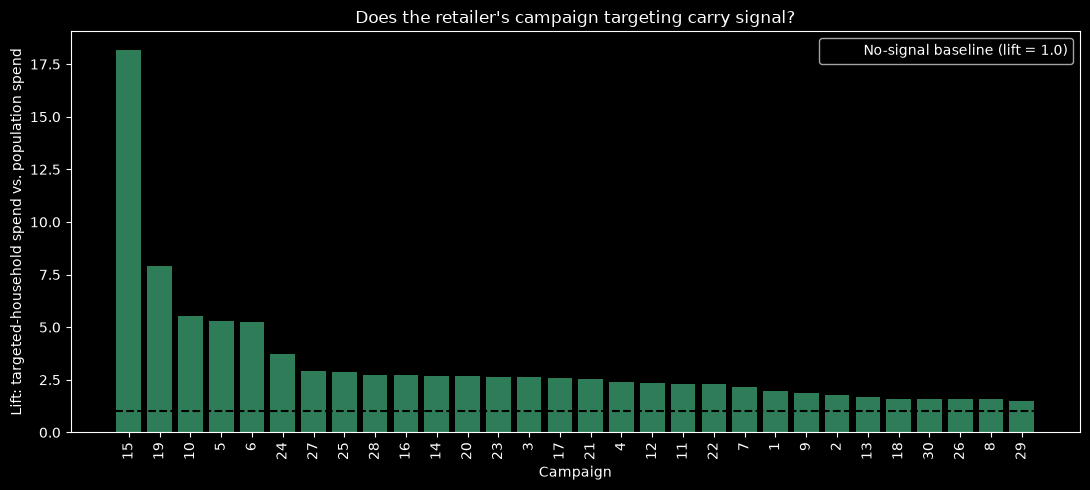

In [33]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#2f7d58" if v > 1 else "#b0413e" for v in targeting_signal["lift"]]
ax.bar(targeting_signal["CAMPAIGN"].astype(str), targeting_signal["lift"], color=colors)
ax.axhline(1.0, color="black", linestyle="--", label="No-signal baseline (lift = 1.0)")
ax.set_xlabel("Campaign")
ax.set_ylabel("Lift: targeted-household spend vs. population spend")
ax.set_title("Does the retailer's campaign targeting carry signal?")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Interpretation — this is the single most important slide in the deck.**

- **Median lift > 1** (and most bars sit above the dashed line): the retailer's assignment already
  concentrates campaigns on households who over-index on the covered commodities. That is a *real*
  baseline — our ALS/ranking model needs to beat this lift, not just beat random assignment, to justify
  itself.
- **Median lift ~= 1** (bars scattered evenly around the line): campaign assignment carries little
  commodity-spend signal. In that case even a mediocre personalization model should show a visible uplift,
  and the honest framing for the capstone becomes "how much better than a low bar can we get," not "how do
  we beat a sophisticated incumbent."

Either reading is a legitimate, useful finding — the point of this check is to know *which* story we are
telling before Tuesday.

## 6. Question 4 — What's the base-rate coupon redemption rate?

In [34]:
coupons_per_campaign = coupon.groupby("CAMPAIGN")["COUPON_UPC"].nunique().rename("n_coupons")
display(coupons_per_campaign.describe().to_frame("coupons_per_campaign"))

,coupons_per_campaign
count,30.0000
mean,46.5667
std,69.3018
min,1.0000
25%,12.2500
50%,17.5000
75%,27.7500
max,209.0000


`coupons_per_campaign` is extremely skewed — from a single coupon on the smallest campaigns to 200+ on the
largest (see the distribution printed above). That skew matters: naively dividing `coupon_redempt` rows by
`campaign_table` rows, and naively weighting every campaign's opportunity count by *all* of its coupons, give
two very different — and both somewhat misleading — answers. We compute three variants side by side rather
than pick one silently.

In [35]:
campaign_table_with_coupons = campaign_table.merge(coupons_per_campaign, on="CAMPAIGN", how="left")
campaign_table_with_coupons["n_coupons"] = campaign_table_with_coupons["n_coupons"].fillna(0)

n_household_campaign_assignments = len(campaign_table)
n_delivery_opportunities = campaign_table_with_coupons["n_coupons"].sum()
n_redemption_events = len(coupon_redempt)

# Variant A — naive event-count rate: redemption EVENTS over ASSIGNMENT rows.
# Overstates the true probability whenever a household redeems more than one coupon
# in the same campaign, since each such redemption is counted again against the
# same single assignment row.
naive_rate = n_redemption_events / n_household_campaign_assignments

# Variant B — the standard marketing definition: the share of assigned
# (household, campaign) pairs that redeemed AT LEAST ONE coupon from that campaign.
assigned_pairs = set(zip(campaign_table["household_key"], campaign_table["CAMPAIGN"]))
redeeming_pairs = set(zip(coupon_redempt["household_key"], coupon_redempt["CAMPAIGN"]))
n_redeeming_pairs = len(assigned_pairs & redeeming_pairs)
household_campaign_redemption_rate = n_redeeming_pairs / len(assigned_pairs)

# Variant C — conservative lower bound: redemption EVENTS over every coupon the
# campaign could in principle have delivered to that household. Assumes a household
# would need to consider every coupon in the campaign as an independent "opportunity",
# which understates the rate badly for campaigns with 100+ unrelated coupons.
opportunity_weighted_rate = n_redemption_events / n_delivery_opportunities

print(f"Household-campaign assignments:                         {n_household_campaign_assignments:,}")
print(f"Redemption events (coupon_redempt rows):                {n_redemption_events:,}")
print(f"Distinct redeeming (household, campaign) pairs:         {n_redeeming_pairs:,}")
print(f"Coupon-delivery opportunities (assignments x coupons):  {n_delivery_opportunities:,.0f}")
print()
print(f"(A) Naive event rate           = redemption events / assignments        = {naive_rate:.2%}")
print(f"(B) Household-campaign rate    = redeeming pairs / assigned pairs       = {household_campaign_redemption_rate:.2%}")
print(f"(C) Opportunity-weighted rate  = redemption events / total coupon slots = {opportunity_weighted_rate:.2%}")

Household-campaign assignments:                         7,208
Redemption events (coupon_redempt rows):                2,318
Distinct redeeming (household, campaign) pairs:         889
Coupon-delivery opportunities (assignments x coupons):  863,670

(A) Naive event rate           = redemption events / assignments        = 32.16%
(B) Household-campaign rate    = redeeming pairs / assigned pairs       = 12.33%
(C) Opportunity-weighted rate  = redemption events / total coupon slots = 0.27%


**Interpretation.** The three variants bracket the true "base rate" rather than pin it down to one number,
and the gap between them is itself informative:

- **(B), ~12%, is the headline number to use going forward.** It answers the actual marketing question —
  "of the household-campaign pairs the retailer targeted, what share redeemed anything?" — without being
  distorted by how many coupons happened to be bundled into a campaign.
- **(A) is inflated** because it counts every redemption *event*, so a household that redeems three coupons
  from one campaign is counted three times against a single assignment row.
- **(C) is a very conservative lower bound**, not a realistic "base rate": it assumes a household would need
  to redeem across every coupon in the campaign (up to 200+ for the largest campaigns) to reach 100%, when in
  practice a household is only ever a plausible redeemer for the handful of coupons matching commodities it
  actually buys.
- Compared to the "single-digit percent" assumption in the brief, **(B) at ~12% is somewhat higher** —
  useful headroom for a targeting model to work with, but the honest framing for the capstone's "money"
  metric is uplift in **(B)-style household-campaign redemption**, not a naive event count. If a smarter
  targeting model pushes this from ~12% to ~18–20% among the households it re-targets, that is a real,
  reportable effect; chasing (A) or (C) as the headline number would over- or under-state the story.

## 7. Question 5 — Is the test window (weeks 97-102) representative?

In [36]:
weekly_sales = transactions.groupby("WEEK_NO")["SALES_VALUE"].sum().sort_index()
weekly_baskets = transactions.groupby("WEEK_NO")["BASKET_ID"].nunique().sort_index()

TEST_WEEK_START = 97
TEST_WEEK_END = int(weekly_sales.index.max())
print(f"Weeks in panel: {weekly_sales.index.min()}-{weekly_sales.index.max()}")
print(f"Test window: {TEST_WEEK_START}-{TEST_WEEK_END} ({TEST_WEEK_END - TEST_WEEK_START + 1} weeks)")

Weeks in panel: 1-102
Test window: 97-102 (6 weeks)


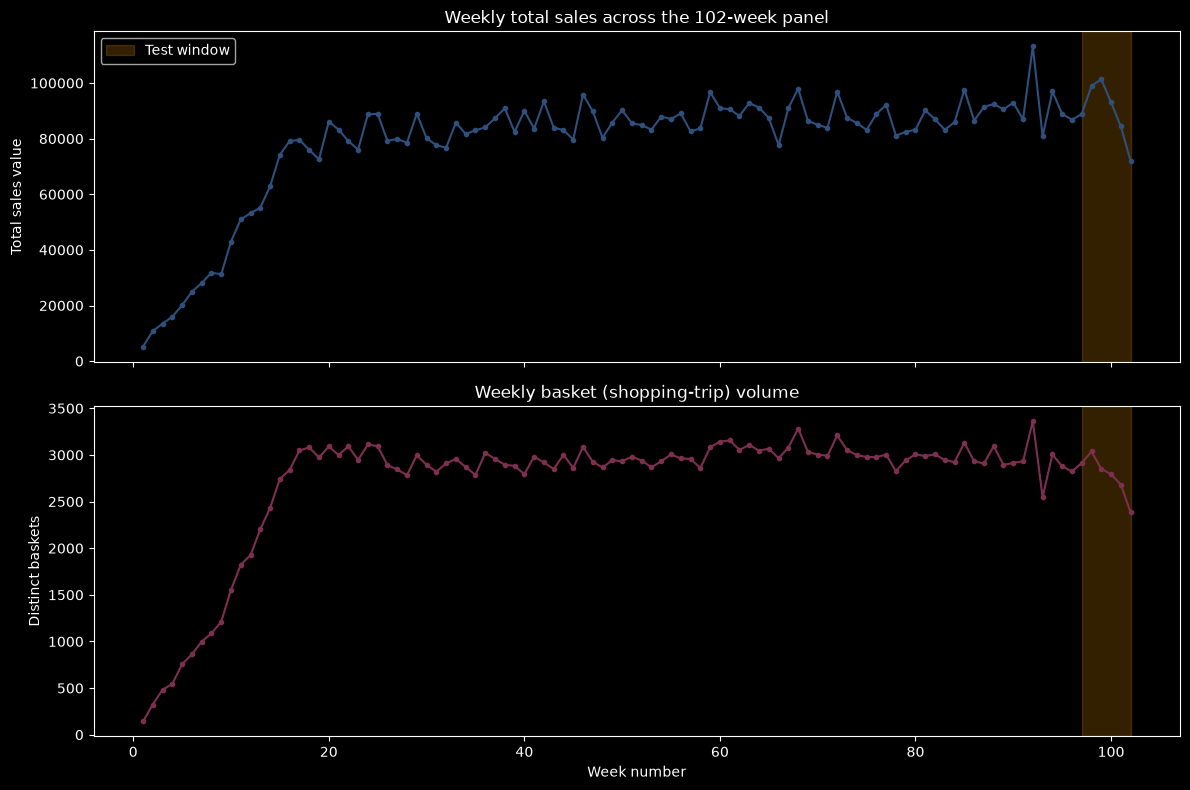

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(weekly_sales.index, weekly_sales.values, marker="o", markersize=3, color="#2f4f7d")
axes[0].axvspan(TEST_WEEK_START, TEST_WEEK_END, color="orange", alpha=0.2, label="Test window")
axes[0].set_ylabel("Total sales value")
axes[0].set_title("Weekly total sales across the 102-week panel")
axes[0].legend()

axes[1].plot(weekly_baskets.index, weekly_baskets.values, marker="o", markersize=3, color="#7d2f4f")
axes[1].axvspan(TEST_WEEK_START, TEST_WEEK_END, color="orange", alpha=0.2)
axes[1].set_xlabel("Week number")
axes[1].set_ylabel("Distinct baskets")
axes[1].set_title("Weekly basket (shopping-trip) volume")

plt.tight_layout()
plt.show()

In [38]:
overall_mean = weekly_sales.mean()
overall_std = weekly_sales.std()
test_mean = weekly_sales.loc[TEST_WEEK_START:TEST_WEEK_END].mean()
test_z = (test_mean - overall_mean) / overall_std

weekly_z = (weekly_sales - overall_mean) / overall_std
anomalous_weeks = weekly_z[weekly_z.abs() > 1.5].sort_values(key=abs, ascending=False)

print(f"Overall weekly mean sales: {overall_mean:,.0f}  (std: {overall_std:,.0f})")
print(f"Test-window ({TEST_WEEK_START}-{TEST_WEEK_END}) mean weekly sales: {test_mean:,.0f}")
print(f"Test-window z-score vs. full-history distribution: {test_z:+.2f}")
print()
print(f"Weeks flagged as anomalous (|z| > 1.5): {len(anomalous_weeks)}")
display(anomalous_weeks.to_frame("z_score"))

Overall weekly mean sales: 78,995  (std: 20,945)
Test-window (97-102) mean weekly sales: 89,765
Test-window z-score vs. full-history distribution: +0.51

Weeks flagged as anomalous (|z| > 1.5): 11


,z_score
WEEK_NO,
1,-3.5228
2,-3.2549
3,-3.1271
4,-3.0093
5,-2.8100
6,-2.5816
7,-2.4312
9,-2.2798
8,-2.2536


**Interpretation.**

- `test_z` close to 0 means weeks 97–102 look like a typical 6-week slice of the panel — safe to use as the
  held-out test window as planned.
- If any of weeks 97–102 appear in the anomalous-weeks table (holiday spikes, promotional pushes, a
  data-collection gap), that is a reason to shift the split earlier/later, or to at least call out the
  anomaly explicitly when reporting test-set metrics, since a spike or trough in that window will move every
  offline metric independent of model quality.

## 8. Question 6 — Demographic coverage sanity check

In [39]:
all_households = set(transactions["household_key"].unique())
demo_households = set(hh_demographic["household_key"].unique())

n_all = len(all_households)
n_covered = len(demo_households & all_households)
n_uncovered = n_all - n_covered

print(f"Total households in transaction_data: {n_all:,}")
print(f"Households WITH demographic data:     {n_covered:,} ({n_covered / n_all:.1%})")
print(f"Households WITHOUT demographic data:  {n_uncovered:,} ({n_uncovered / n_all:.1%})")

Total households in transaction_data: 2,500
Households WITH demographic data:     801 (32.0%)
Households WITHOUT demographic data:  1,699 (68.0%)


In [40]:
household_total_spend = transactions.groupby("household_key")["SALES_VALUE"].sum().rename("total_spend")

spend_df = household_total_spend.reset_index()
spend_df["has_demographics"] = spend_df["household_key"].isin(demo_households)

coverage_spend_summary = spend_df.groupby("has_demographics")["total_spend"].agg(
    ["count", "mean", "median", "std"]
)
display(coverage_spend_summary)

,count,mean,median,std
has_demographics,,,,
False,1699,"2,095.2012","1,396.9299","2,430.2451"
True,801,"5,615.1260","4,676.4302","3,750.9387"


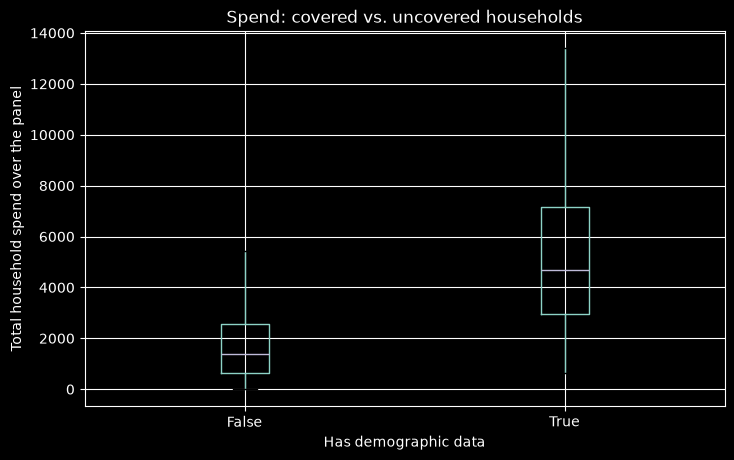

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
spend_df.boxplot(column="total_spend", by="has_demographics", ax=ax, showfliers=False)
ax.set_xlabel("Has demographic data")
ax.set_ylabel("Total household spend over the panel")
ax.set_title("Spend: covered vs. uncovered households")
plt.suptitle("")
plt.show()

In [42]:
# Bootstrap 95% CI for the mean-spend difference (covered - uncovered), no scipy required
covered_spend = spend_df.loc[spend_df["has_demographics"], "total_spend"].to_numpy()
uncovered_spend = spend_df.loc[~spend_df["has_demographics"], "total_spend"].to_numpy()

N_BOOT = 2000
boot_diffs = np.empty(N_BOOT)
for i in range(N_BOOT):
    c_sample = rng.choice(covered_spend, size=len(covered_spend), replace=True)
    u_sample = rng.choice(uncovered_spend, size=len(uncovered_spend), replace=True)
    boot_diffs[i] = c_sample.mean() - u_sample.mean()

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
mean_diff = covered_spend.mean() - uncovered_spend.mean()
pct_diff = mean_diff / uncovered_spend.mean()

print(f"Mean spend, covered households:   {covered_spend.mean():,.2f}")
print(f"Mean spend, uncovered households: {uncovered_spend.mean():,.2f}")
print(f"Relative difference: {pct_diff:+.1%}")
print(f"Bootstrap 95% CI for (covered mean - uncovered mean): [{ci_low:,.2f}, {ci_high:,.2f}]")

coverage_is_nonrandom = (ci_low > 0) or (ci_high < 0)
print("=> Coverage looks NON-RANDOM with respect to spend." if coverage_is_nonrandom
      else "=> Coverage difference is not clearly distinguishable from zero.")

Mean spend, covered households:   5,615.13
Mean spend, uncovered households: 2,095.20
Relative difference: +168.0%
Bootstrap 95% CI for (covered mean - uncovered mean): [3,246.80, 3,801.97]
=> Coverage looks NON-RANDOM with respect to spend.


**Interpretation.** `hh_demographic` covers roughly 800 of the ~2,500 households. If the bootstrap interval
excludes zero, the covered households are *not* a random sample — usually the households who filled out a
loyalty-card demographic survey are systematically higher- or lower-spend than those who didn't. In that
case, feeding demographics into ALS as a side-feature without accounting for the ~68% of households missing
them (e.g. via a missingness indicator, imputation, or excluding demographics from the core model and using
them only for a covered-subset analysis) will bias the model toward whatever behaviour is typical of the
covered 800. **This must be flagged explicitly in the project's limitations paragraph.**

## 9. Executive summary

In [43]:
summary_md = f"""
| # | Question | Finding |
|---|---|---|
| 1 | Household x commodity sparsity | {n_households:,} households x {n_commodities} commodities -> density **{density_commodity:.2%}** (department-level fallback: {density_department:.2%}) |
| 2 | Household activity distribution | **{near_cold:,}** households ({near_cold / n_hh:.1%}) near-cold (<10 baskets); **{heavy:,}** ({heavy / n_hh:.1%}) heavy shoppers (>500 baskets) |
| 3 | Retailer targeting signal | Median lift across {len(targeting_signal)} campaigns = **{median_lift:.2f}x** population spend ({share_above_one:.0%} of campaigns show lift > 1) |
| 4 | Base-rate coupon redemption | Headline **{household_campaign_redemption_rate:.2%}** of targeted household-campaign pairs redeemed >=1 coupon (bracketed by naive event rate {naive_rate:.2%} and opportunity-weighted lower bound {opportunity_weighted_rate:.2%}) |
| 5 | Test-window representativeness | Weeks {TEST_WEEK_START}-{TEST_WEEK_END} z-score = **{test_z:+.2f}**; {len(anomalous_weeks)} anomalous week(s) flagged in the full panel |
| 6 | Demographic coverage | **{n_covered:,} / {n_all:,}** households ({n_covered / n_all:.1%}) covered; spend difference 95% CI = [{ci_low:,.0f}, {ci_high:,.0f}] ({"non-random" if coverage_is_nonrandom else "not distinguishable from random"}) |
"""
display(Markdown(summary_md))


| # | Question | Finding |
|---|---|---|
| 1 | Household x commodity sparsity | 2,500 households x 308 commodities -> density **37.18%** (department-level fallback: 27.89%) |
| 2 | Household activity distribution | **98** households (3.9%) near-cold (<10 baskets); **35** (1.4%) heavy shoppers (>500 baskets) |
| 3 | Retailer targeting signal | Median lift across 30 campaigns = **2.55x** population spend (100% of campaigns show lift > 1) |
| 4 | Base-rate coupon redemption | Headline **12.33%** of targeted household-campaign pairs redeemed >=1 coupon (bracketed by naive event rate 32.16% and opportunity-weighted lower bound 0.27%) |
| 5 | Test-window representativeness | Weeks 97-102 z-score = **+0.51**; 11 anomalous week(s) flagged in the full panel |
| 6 | Demographic coverage | **801 / 2,500** households (32.0%) covered; spend difference 95% CI = [3,247, 3,802] (non-random) |


## 10. Limitations to carry into the write-up

1. **Demographic coverage is likely non-random** (Q6). Do not use `hh_demographic` fields as unconditional
   ALS side-features; either restrict the demographics-aware analysis to the covered subset, add an explicit
   missingness indicator, or weight/re-balance before use.
2. **Targeting-signal lift (Q3) is correlational, not causal.** Households may be assigned to a campaign
   *because* of attributes correlated with commodity spend (e.g. household size, prior loyalty tier) rather
   than the retailer explicitly optimizing on commodity-level spend. Treat the lift as "the bar the model
   must clear," not as evidence of a specific targeting algorithm.
3. **Returns are netted, not dropped** (Q1 data quality). Household x commodity spend nets returns against
   purchases; a commodity with heavy returns could show artificially low net spend even with high gross
   purchase activity.
4. **Orphan SKUs are silently dropped** from the commodity-level matrix via the inner join in Section 3 —
   re-check the drop percentage (Section 2.3) any time the raw data files are refreshed.
5. **The household x commodity density in Q1 is a lifetime (102-week) coverage number, not a per-basket
   one.** It is not directly comparable to the "5-8% per-trip" rule of thumb quoted in the brief; report it
   alongside that caveat rather than as a like-for-like figure.
6. **"Coupon redemption rate" is ambiguous and the three variants in Q4 disagree by two orders of
   magnitude** (12% vs. 32% vs. 0.27%). Always state which definition is being used when this number is
   quoted later in the project — the recommendation here is the household-campaign "redeemed >=1" rate.
7. **`causal_data.csv` was not analyzed here** beyond a row-count sanity check; display/mailer features from
   that table are a natural extension once the core sparsity/targeting/redemption picture is settled.